In [196]:
#Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy.physics.mechanics import dynamicsymbols
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are
import matplotlib.animation as animation
import pandas as pd

In [3]:
#System physical parameters
m = 1.0         # Mass at the end of the pole
M = 5.0         # Mass of the cart
g = 9.81        # Gravity
L = 0.75        # Length of pole
F_MAX = 20.0    # Max force motor is capable of

#Solving for gain matrix for LQR by hand
A = np.array([[0, 1, 0, 0],
              [0, 0, m*g/M, 0],
              [0, 0, 0, 1],
              [0, 0, (M+m)*g/(M*L), 0]])
 
B = np.array([0, 1/M, 0, 1/(M*L)]).reshape(-1, 1)

Q = np.diag([0.1, 1, 50, 400])

R = np.array([[1/F_MAX**2]])

P = solve_continuous_are(A, B, Q, R)
K = np.linalg.inv(R) @ B.T @ P
K = K.flatten()

#Keeps angle within [-pi, pi]
def wrap_angle(theta):
    angle = (theta + np.pi) % (2*np.pi) - np.pi
    return angle

In [314]:
#Controller Parameters
mode = "heuristic"
hand_off_theta = np.radians(25)
hand_off_thd = np.radians(400)
target = np.array([0, 0, np.pi, 0])     # Desired state is [x=0, x_dot=0, theta=pi, theta_dot=0]

def lqr_controller(state):
    error = state - target  
    error[2] = wrap_angle(error[2])
    F = -K @ error
    F = np.clip(F, -F_MAX, F_MAX)   #Motor saturation, small default force to help stationary start
    return F

#Uses angular velocity and angle error to calculate force
def heuristic_swingup(state):
    F = -F_MAX * state[3] * np.cos(state[2])
    if np.sign(F) == np.sign(state[0]):
            F = F * 0.4  # Reduce the force if the cart is moving in the same direction as the position error
    F = np.clip(F, -F_MAX, F_MAX)
    return F

Ke = 20     #Energy error gain
Kcp = 0.4  #Cart position error gain
#Energy-based swingup method
def energy_swingup(state):
    error = state - target
    error[2] = wrap_angle(error[2])
    KE = 0.5 * m * (L * state[3])**2
    PE = -m*g*L*np.cos(state[2])
    E = KE + PE
    E_desired = m*g*L
    E_error = E - E_desired

    F_swing = Ke * (E_error) * np.sign(state[3] * np.cos(state[2]))
    F_cart = -Kcp * state[0]
    F = F_cart + F_swing
    F = np.clip(F, -F_MAX, F_MAX)
    return F

def hybrid_controller(state, mode):
    error = state - target
    error[2] = wrap_angle(error[2])

    if abs(error[2]) < hand_off_theta:
        return lqr_controller(state)
    
    if mode == "heuristic":
        if abs(state[3]) < hand_off_thd:
            return heuristic_swingup(state)
        else:
            return -heuristic_swingup(state)
        
    elif mode == "energy":
        return energy_swingup(state)

#Simulation function
def derivatives(t, state):
    x, x_dot, theta, theta_dot = state
    F = hybrid_controller(state, mode)
    s, c = np.sin(theta), np.cos(theta)
    denom = M + m * s**2
    x_ddot = (F + m * s * (L * theta_dot**2 + g * c)) / denom
    theta_ddot = (-(M + m)*g*s - F*c - m*L*s*c*theta_dot**2) / (L * denom)
    return [x_dot, x_ddot, theta_dot, theta_ddot]

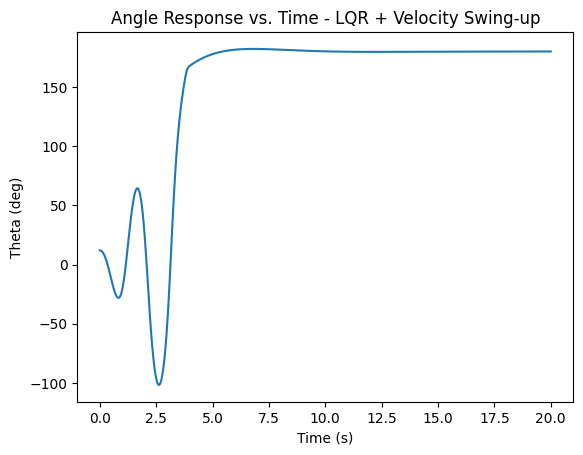

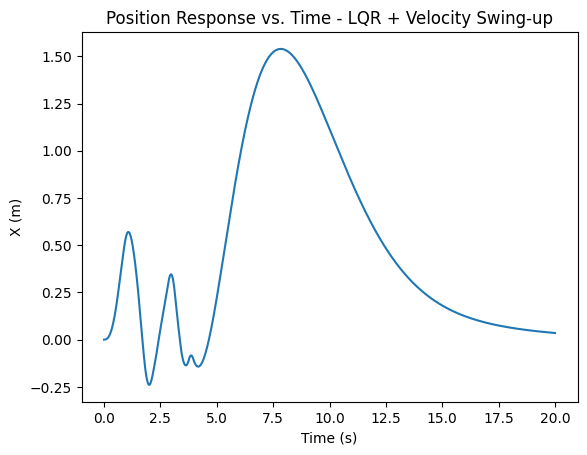

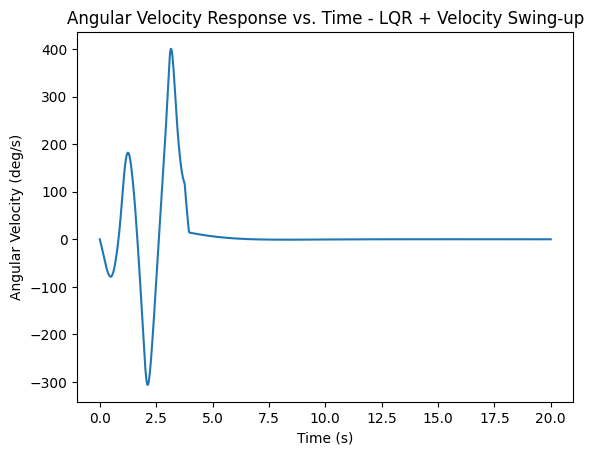

In [316]:
#Setting initial state and running simulation with control
theta0 = np.radians(12)
theta_dot0 = np.radians(0)
x0 = 0.0
x_dot0 = 0.0
state0 = [x0, x_dot0, theta0, theta_dot0]

t_end = 20
fps = 50
t_eval = np.linspace(0, t_end, t_end*fps)

sol = solve_ivp(derivatives, [0, t_end], state0, t_eval=t_eval, rtol=1e-6, atol=1e-6)
x, x_dot, theta, theta_dot = sol.y
t = sol.t

plt.plot(t, np.degrees(theta))
plt.xlabel('Time (s)')
plt.ylabel('Theta (deg)')
plt.title("Angle Response vs. Time - LQR + Velocity Swing-up")
plt.show()

plt.plot(t, x)
plt.xlabel('Time (s)')
plt.ylabel('X (m)')
plt.title("Position Response vs. Time - LQR + Velocity Swing-up")
plt.show()

plt.plot(t, np.degrees(theta_dot))
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (deg/s)')
plt.title("Angular Velocity Response vs. Time - LQR + Velocity Swing-up")
plt.show()

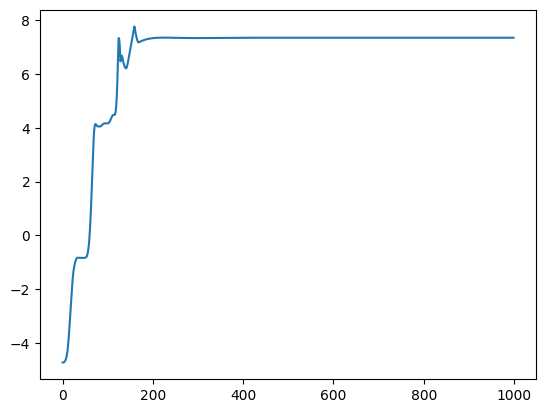

In [288]:
KE_sol = 0.5 * m * (L * theta_dot)**2
PE_sol = m * g * (-L * np.cos(theta))

Energies = KE_sol + PE_sol

plt.plot(Energies)

KeyboardInterrupt: 

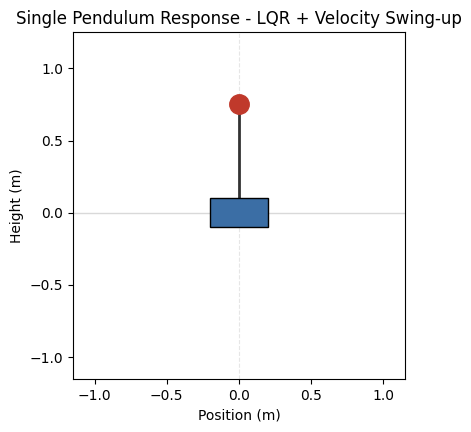

In [249]:
#Animating Pendulum Response

bob_x = x + L * np.sin(theta)
bob_y = -L * np.cos(theta)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.set_xlim(x.min() - L - 0.4, x.max() + L + 0.4)
ax.set_ylim(-L - 0.4, L + 0.5)
ax.set_aspect('equal')
ax.axhline(0, color='0.85', lw=1)
ax.axvline(0, color='0.9', lw=0.8, ls='--')      # cart target position
ax.set_title("Single Pendulum Response - LQR + Velocity Swing-up")
ax.set_xlabel("Position (m)")
ax.set_ylabel("Height (m)")
 
cart_w, cart_h = 0.4, 0.2
cart = plt.Rectangle((0, -cart_h/2), cart_w, cart_h, fc='#3b6ea5', ec='k', zorder=3)
ax.add_patch(cart)
rod,   = ax.plot([], [], '-', color='#333', lw=2, zorder=2)
bob,   = ax.plot([], [], 'o', color='#c0392b', ms=14, zorder=4)
 
def animate(i):
    cx = x[i]
    cart.set_xy((cx - cart_w/2, -cart_h/2))
    rod.set_data([cx, bob_x[i]], [0, bob_y[i]])
    bob.set_data([bob_x[i]], [bob_y[i]])
    scale = 0.06
    return cart, rod, bob

ani = animation.FuncAnimation(fig, animate, frames=len(t_eval),
                              interval=1000/fps, blit=True)

writer = animation.FFMpegWriter(fps=fps, codec='libx264',
                                extra_args=['-preset', 'ultrafast', '-pix_fmt', 'yuv420p'])
ani.save("../figures/single_pendulum_LQR_energy.mp4", writer=writer, dpi=200)

In [ ]:
#Controller metrics

THETA_TOL = np.radians(2.0)
OMEGA_TOL = np.radians(5.0)
HOLD     = 0.5      # must stay in band this long before t_end to count

def settling_time(t, theta, theta_dot):
    error = np.abs(wrap_angle(theta - np.pi))

    for i in range(len(t)):
        if error[i] < THETA_TOL and abs(theta_dot[i]) < OMEGA_TOL:

            # Find the index corresponding to HOLD seconds later
            j = np.searchsorted(t, t[i] + HOLD)

            # Make sure we have enough simulation left
            if j >= len(t):
                return np.nan

            # Check if it stayed within the tolerances
            if np.all(error[i:j] < THETA_TOL) and np.all(np.abs(theta_dot[i:j]) < OMEGA_TOL):
                return t[i]

    return np.nan

initial_angles = np.linspace(np.radians(5), np.radians(180), 50)

mode = 'heuristic'
results = []
for th0 in initial_angles:
    sol = solve_ivp(derivatives, [0, t_end], [x0, x_dot0, th0, theta_dot0],
                    t_eval=t_eval, rtol=1e-6, atol=1e-6)
    x, x_dot, theta, theta_dot = sol.y
    ts = settling_time(sol.t, theta, theta_dot)
    ok = sol.success and not np.isnan(ts)
    results.append(dict(
        theta0    = np.degrees(th0),
        success   = ok,
        settle    = ts,
        max_x     = x.max()      if ok else np.nan,
        min_x     = x.min()      if ok else np.nan,
        track     = np.ptp(x)    if ok else np.nan,
    ))

df_heuristic = pd.DataFrame(results)
print(f"success: {df_heuristic.success.mean():.1%}  "
      f"median settle: {df_heuristic.settle.median():.2f}s  "
      f"worst track: {df_heuristic.track.max():.2f}m")

#Same for energy-based controller:
mode = 'energy'
results = []
for th0 in initial_angles:
    sol = solve_ivp(derivatives, [0, t_end], [x0, x_dot0, th0, theta_dot0],
                    t_eval=t_eval, rtol=1e-6, atol=1e-6)
    x, x_dot, theta, theta_dot = sol.y
    ts = settling_time(sol.t, theta, theta_dot)
    ok = sol.success and not np.isnan(ts)
    results.append(dict(
        theta0    = np.degrees(th0),
        success   = ok,
        settle    = ts,
        max_x     = x.max()      if ok else np.nan,
        min_x     = x.min()      if ok else np.nan,
        track     = np.ptp(x)    if ok else np.nan,
    ))

df_energy = pd.DataFrame(results)
print(f"success: {df_energy.success.mean():.1%}  "
      f"median settle: {df_energy.settle.median():.2f}s  "
      f"worst track: {df_energy.track.max():.2f}m")

success: 100.0%  median settle: 5.76s  worst track: 6.07m
success: 100.0%  median settle: 5.90s  worst track: 10.48m


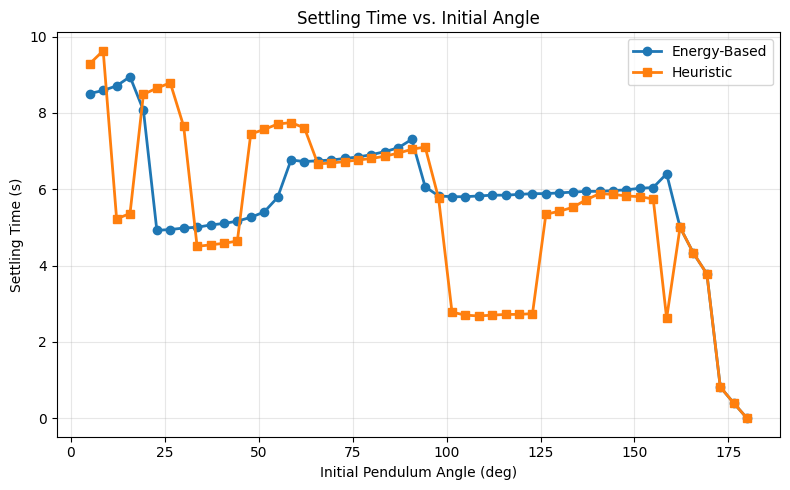

In [310]:
plt.figure(figsize=(8,5))

plt.plot(
    df_energy.theta0,
    df_energy.settle,
    marker='o',
    linewidth=2,
    label='Energy-Based'
)

plt.plot(
    df_heuristic.theta0,
    df_heuristic.settle,
    marker='s',
    linewidth=2,
    label='Heuristic'
)

plt.xlabel("Initial Pendulum Angle (deg)")
plt.ylabel("Settling Time (s)")
plt.title("Settling Time vs. Initial Angle")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

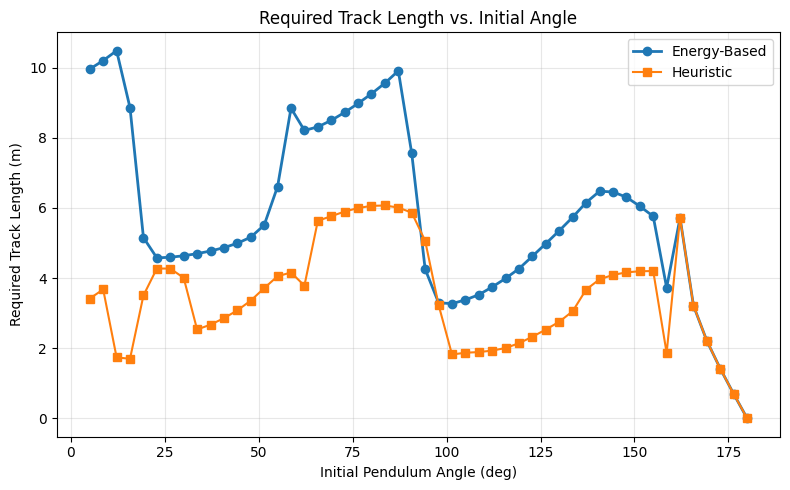

3.4588192036774705
5.257097683633044
6.067190065689861
-4.198478267843797


In [317]:
plt.figure(figsize=(8,5))

plt.plot(
    df_energy.theta0,
    df_energy.track,
    marker='o',
    linewidth=2,
    label='Energy-Based'
)

plt.plot(
    df_heuristic.theta0,
    df_heuristic.track,
    marker='s',
    linewidth=1.5,
    label='Heuristic'
)

plt.xlabel("Initial Pendulum Angle (deg)")
plt.ylabel("Required Track Length (m)")
plt.title("Required Track Length vs. Initial Angle")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(np.median(df_heuristic.track))
print(np.median(df_energy.track))
print(df_heuristic.max_x.max())
print(df_heuristic.min_x.min())